# Zheng et al. (2017) – Massively parallel digital transcriptional profiling of single cells

The original paper can be found here: https://www.nature.com/articles/ncomms14049

__Abstract__: Characterizing the transcriptome of individual cells is fundamental to understanding complex biological systems. We describe a droplet-based system that enables 3′ mRNA counting of tens of thousands of single cells per sample. Cell encapsulation, of up to 8 samples at a time, takes place in ∼6 min, with ∼50% cell capture efficiency. To demonstrate the system’s technical performance, we collected transcriptome data from ∼250k single cells across 29 samples. We validated the sensitivity of the system and its ability to detect rare populations using cell lines and synthetic RNAs. We profiled 68k peripheral blood mononuclear cells to demonstrate the system’s ability to characterize large immune populations. Finally, we used sequence variation in the transcriptome data to determine host and donor chimerism at single-cell resolution from bone marrow mononuclear cells isolated from transplant patients.

A 10x Chromium immune benchmark: ~14k human PBMCs assembled from FACS-sorted populations (CD14⁺ monocytes, B cells, NK, CD4/8 T, &c.). The data set is UMI-based droplet data, and can be used as a multi-class ground truth because the cells come from purified sorts.

From scMINER: The data of this study was originally collected from SRP073767 and used as a ground truth to benchmark scMINER and other tools. In this study, the authors performed single cell RNA-Seq experiment on 10 sorted populations of Peripheral Blood Mononuclear Cells (PBMCs): CD14+ Monocyte, CD19+ B, CD34+, CD4+ T Helper2, CD4+/CD25 T Reg, CD4+/CD45RA+/CD25- Naive T, CD4+/CD45RO+ Memory, CD56+ NK, CD8+ Cytotoxic T, CD8+/CD45RA+ Naive Cytotoxic. The library was prepared with GemCode Single-Cell 3′ Gel Bead and Library Kit (10x Genomics) and sequenced on NextSeq 500 (Illumina). For benchmark purpuses, we removed 3 cell populations, CD34+ cells, CD4+ helper T cells, and total CD8+ cytotoxic cells, from the dataset because of either low sorting purity or a significant overlap with other immune cells based on the sorting strategy, and created a new dataset with seven known cell types and 14k cells in total. Zheng, Grace XY, et al. "Massively parallel digital transcriptional profiling of single cells." Nature communications 8.1 (2017): 14049.

## 0. Imports & Set-Up:

In [40]:
# add Leiden!

from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances, adjusted_rand_score
from sklearn.preprocessing import FunctionTransformer

import umap
from umap import UMAP

import numpy as np
import pandas as pd

import scanpy as sc
import anndata as ad, io, gzip, os

import matplotlib.pyplot as plt

from carve import CARVE
from carve.config import ValidatorConfig

from pathlib import Path

In [41]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


---

## 1. Pre-Process the Data

In [42]:
DATA_DIR = "../data/Zheng PBMC14K"
FP_EXPR = f"{DATA_DIR}/Filtered_DownSampled_SortedPBMC_data.csv"
FP_ANN  = f"{DATA_DIR}/GRCh37.87.geneAnnotation.txt"
FP_LAB  = f"{DATA_DIR}/PBMC_20k_true_label.txt"

Read in annotation data:

In [43]:
expr = pd.read_csv(FP_EXPR, index_col=0)

# consider orientation: if rows >> cols and looks like genes x cells, transpose to cells x genes
if expr.shape[0] < expr.shape[1]:
    print('already cells x genes')
    Xdf = expr
else:
    print('genes x cells -> transpose to cells x genes')
    Xdf = expr.T

already cells x genes


Ensure numeric:

In [44]:
Xdf = Xdf.apply(pd.to_numeric, errors="coerce")
Xdf = Xdf.loc[:, Xdf.notna().any(axis=0)].fillna(0.0)

print("cells x genes:", Xdf.shape)

cells x genes: (20000, 21952)


Read true labels (txt; usually tab-separated with columns like ID, label):

In [45]:
lab = pd.read_csv(FP_LAB, sep="\t")
    
# try 
candidates_id = [c for c in lab.columns if c.lower() in {"id", "barcode", "cell", "cell_id"}]
candidates_lb = [c for c in lab.columns if "label" in c.lower() or "type" in c.lower() or "pop" in c.lower()]

if not candidates_id or not candidates_lb:
    print("Label columns:", lab.columns.tolist())
    raise ValueError("Could not infer ID/label columns—inspect printed columns and set manually.")

id_col, lb_col = candidates_id[0], candidates_lb[0]
lab = lab[[id_col, lb_col]].rename(columns={id_col: "cell_id", lb_col: "cell_type"})
lab["cell_id"] = lab["cell_id"].astype(str)
lab["cell_type"] = lab["cell_type"].astype("category")

lab = lab.set_index("cell_id")

Align by intersection of "cell_id":

In [46]:
common = Xdf.index.astype(str).intersection(lab.index)
if len(common) == 0:
    # Sometimes barcodes in matrix have suffixes like "-1"; try stripping
    X_index = Xdf.index.astype(str).str.replace("-1$", "", regex=True)
    Xdf.index = X_index
    common = Xdf.index.intersection(lab.index)

Xdf = Xdf.loc[common]
lab = lab.loc[common]
print("aligned cells:", Xdf.shape[0])

aligned cells: 20000


Gene annotation, add gene symbols for var:

In [47]:
ann = pd.read_csv(FP_ANN, sep="\t")

# try to guess columns
ens_cols = [c for c in ann.columns if "ensembl" in c.lower() or c.lower() in {"gene_id", "ensembl_gene_id"}]
sym_cols = [c for c in ann.columns if "symbol" in c.lower() or c.lower() in {"hgnc_symbol", "gene_name"}]

if ens_cols and sym_cols:
    ens_col, sym_col = ens_cols[0], sym_cols[0]
    ann = ann[[ens_col, sym_col]].dropna()
    ann[ens_col] = ann[ens_col].astype(str)
    ann = ann.drop_duplicates(subset=[ens_col]).set_index(ens_col)
    
    # If Xdf columns are Ensembl IDs, can map; otherwise store names as-is
    var = pd.DataFrame(index=pd.Index(Xdf.columns.astype(str), name="gene_id"))
    
    if var.index.isin(ann.index).any():
        var["gene_symbol"] = ann.reindex(var.index)[sym_col].values
    else:
        # Xdf already uses symbols?
        var = var.rename_axis("gene_symbol").copy()
else:
    var = pd.DataFrame(index=pd.Index(Xdf.columns.astype(str), name="gene_id"))

Build adata object:

In [48]:
# Remove cell populations from lab and Xdf as scMINER
exclude_types = [
    "CD34+",
    "CD4+ T Helper2",
    "CD8+ Cytotoxic T"
]
keep_cells = lab[~lab["cell_type"].isin(exclude_types)].index
Xdf = Xdf.loc[keep_cells]
lab = lab.loc[keep_cells]

adata = ad.AnnData(
    X = Xdf.values.astype(np.float32),  # raw UMI counts
    obs = pd.DataFrame(index=pd.Index(Xdf.index.astype(str), name="barcode")),
    var = var,
)
adata.obs["cell_type"] = lab["cell_type"].astype("category")
adata.layers["counts"] = adata.X.copy()  # preserve raw counts

# name hygiene so .write() works cleanly
adata.obs.columns = adata.obs.columns.astype(str)
adata.var.columns = adata.var.columns.astype(str)
adata.obs_names.name = "barcode"
adata.var_names = adata.var_names.astype(str)
adata.var_names.name = adata.var_names.name or "gene_id"

adata.obs["cell_type"] = adata.obs["cell_type"].cat.remove_unused_categories()

print(adata)
print(adata.obs["cell_type"].value_counts())

AnnData object with n_obs × n_vars = 14000 × 21952
    obs: 'cell_type'
    layers: 'counts'
cell_type
CD14+ Monocyte                  2000
CD19+ B                         2000
CD4+/CD25 T Reg                 2000
CD4+/CD45RA+/CD25- Naive T      2000
CD4+/CD45RO+ Memory             2000
CD56+ NK                        2000
CD8+/CD45RA+ Naive Cytotoxic    2000
Name: count, dtype: int64


---

## 2. Analyse Data

In [49]:
print(f"np.unique(obs): {np.unique(adata.obs['cell_type'].values)}")
print(f"len(np.unique(obs)): {len(np.unique(np.unique(adata.obs['cell_type'].values)))}")

np.unique(obs): ['CD14+ Monocyte' 'CD19+ B' 'CD4+/CD25 T Reg' 'CD4+/CD45RA+/CD25- Naive T'
 'CD4+/CD45RO+ Memory' 'CD56+ NK' 'CD8+/CD45RA+ Naive Cytotoxic']
len(np.unique(obs)): 7


In [50]:
# extract X (cells × genes) from AnnData into a pandas DataFrame
X = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)
y = adata.obs['cell_type'].values
print("X.shape:", X.shape)

X.shape: (14000, 21952)


In [51]:
y.shape

(14000,)

PCA plot of raw gene counts:

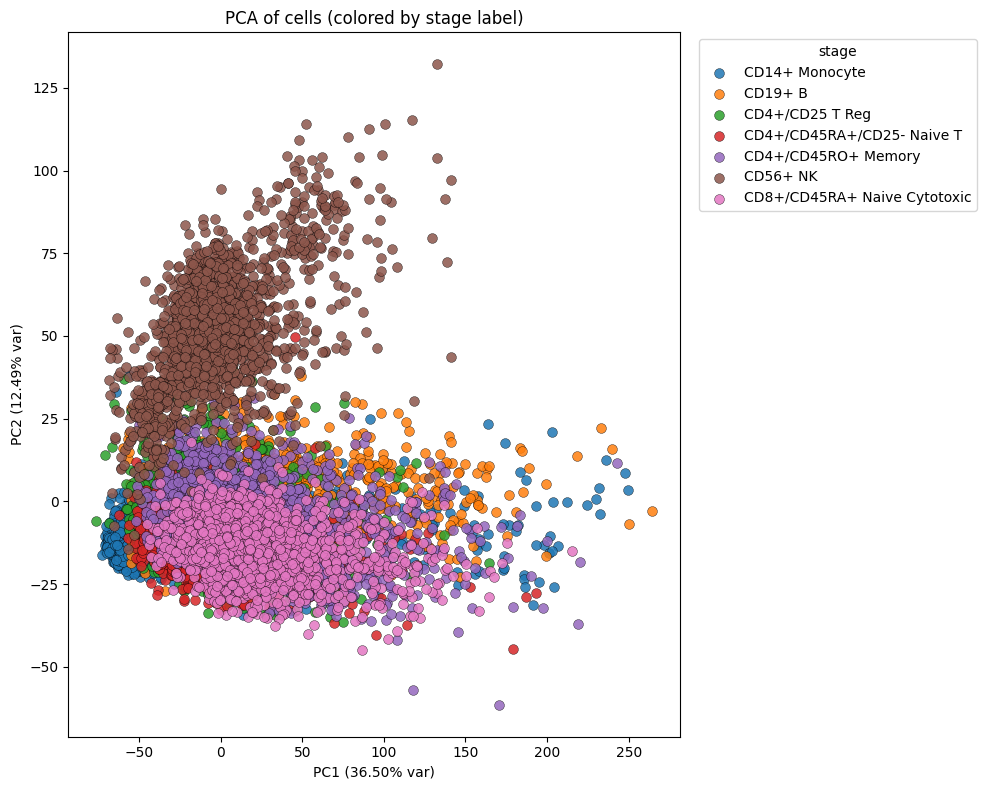

In [52]:
# PCA on cells (samples are columns of X) and scatter plot colored by y
pca = PCA(n_components=2)
pcs = pca.fit_transform(X)  # shape: (n_cells, 2)

pc_df = pd.DataFrame(pcs, index=X.index, columns=['PC1', 'PC2'])
pc_df['label'] = y

plt.figure(figsize=(10, 8))
labels = pd.Categorical(pc_df['label']).categories
cmap = plt.get_cmap('tab10')
color_map = {lab: cmap(i % 10) for i, lab in enumerate(labels)}

for lab in labels:
    sel = pc_df[pc_df['label'] == lab]
    plt.scatter(sel['PC1'], sel['PC2'], label=lab, color=color_map[lab], s=50, alpha=0.85, edgecolor='k', linewidth=0.3)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% var)")
plt.title("PCA of cells (colored by stage label)")
plt.legend(title='stage', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Normalize and Select Highly-Variable Genes:

In [53]:
print(adata.obs.columns)

Index(['cell_type'], dtype='object')


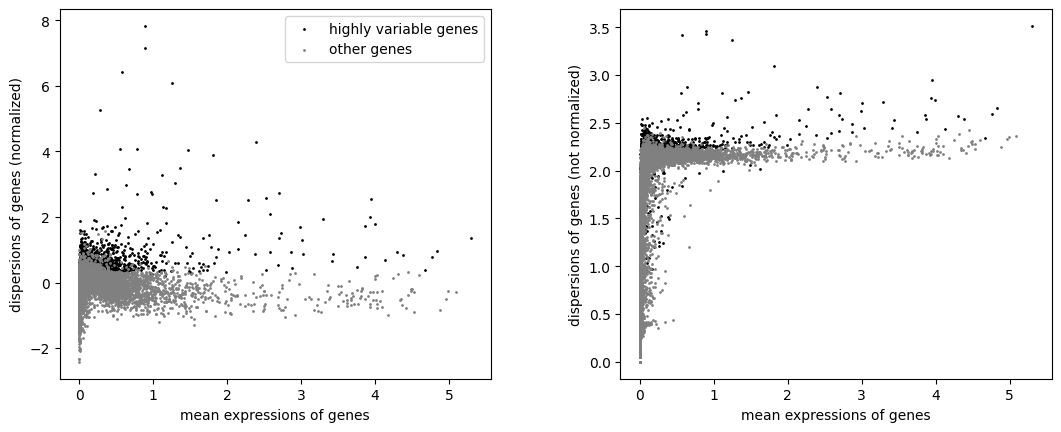

In [54]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="cell_type", flavor='seurat')
sc.pl.highly_variable_genes(adata)

Subset to HVGs only:

In [55]:
adata = adata[:, adata.var["highly_variable"]].copy()

In [56]:
# # Overwrite X and y using the (HVG-subset) adata
X = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)

print("X.shape:", X.shape)
print("y.shape:", y.shape)

X.shape: (14000, 2000)
y.shape: (14000,)


PCA of log1p transformed 500 HVGs:

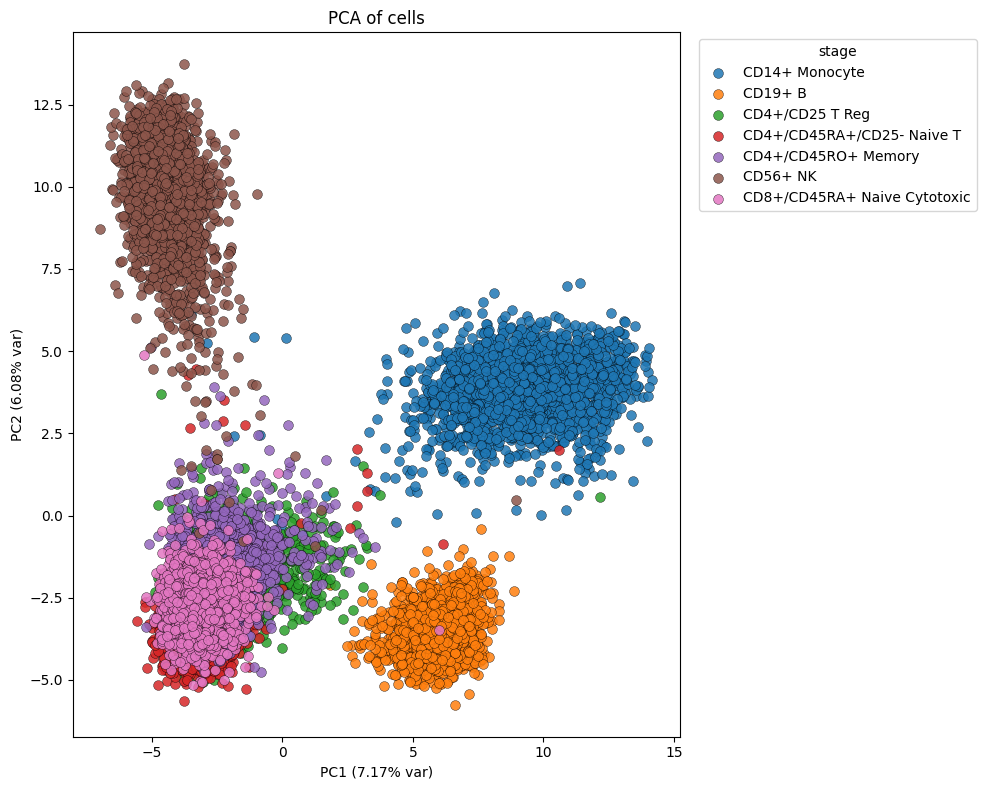

In [57]:
pca = PCA(n_components=2)
pcs = pca.fit_transform(X)

pc_df = pd.DataFrame(pcs, index=X.index, columns=['PC1', 'PC2'])
pc_df['label'] = y

plt.figure(figsize=(10, 8))
labels = pd.Categorical(pc_df['label']).categories
cmap = plt.get_cmap('tab10')
color_map = {lab: cmap(i % 10) for i, lab in enumerate(labels)}

for lab in labels:
    sel = pc_df[pc_df['label'] == lab]
    plt.scatter(sel['PC1'], sel['PC2'], label=lab, color=color_map[lab], s=50, alpha=0.85, edgecolor='k', linewidth=0.3)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% var)")
plt.title("PCA of cells")
plt.legend(title='stage', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

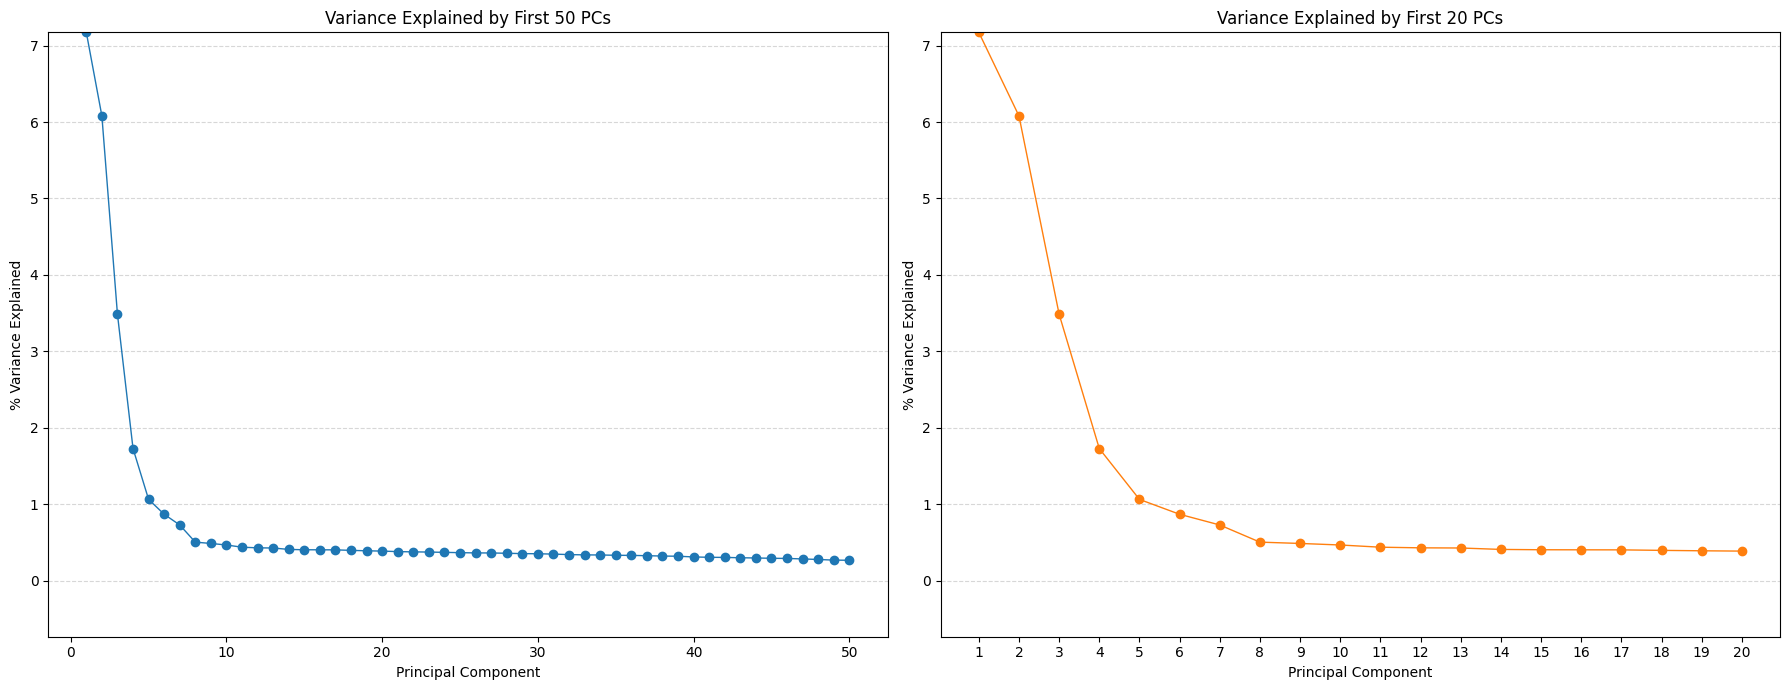

In [59]:
num_pcs = 50

pca = PCA(n_components=num_pcs)
pcs = pca.fit_transform(X)

fig, ax = plt.subplots(1, 2, figsize=(18, 7))
ymin = min(pca.explained_variance_ratio_[:num_pcs] * 100).min() - 1
ymax = max(pca.explained_variance_ratio_[:num_pcs] * 100).max()
ax[0].set_ylim(ymin, ymax)
ax[1].set_ylim(ymin, ymax)

ax[0].plot(np.arange(1, num_pcs + 1), pca.explained_variance_ratio_[:num_pcs] * 100, marker='o', linewidth=1)
ax[0].set_xlabel('Principal Component')
ax[0].set_ylabel('% Variance Explained')
ax[0].set_title(f'Variance Explained by First {num_pcs} PCs')
ax[0].set_xticks(np.arange(0, num_pcs + 1, 10))
ax[0].grid(axis='y', linestyle='--', alpha=0.5)

ax[1].plot(np.arange(1, 21), pca.explained_variance_ratio_[:20] * 100, marker='o', linewidth=1, color='tab:orange')
ax[1].set_xlabel('Principal Component')
ax[1].set_ylabel('% Variance Explained')
ax[1].set_title('Variance Explained by First 20 PCs')
ax[1].set_xticks(np.arange(1, 21, 1))
ax[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Find largest drop in explained variance ratio between PCs ~9 and 20:

In [60]:
start = 9
end = 20

expl_var = pca.explained_variance_ratio_[:20] * 100
diffs = np.diff(expl_var)

drop_start = start - 1  # PC12 is index 11
drop_end = end - 1  # PC20 is index 19
drop_idx = np.argmin(diffs[drop_start:drop_end]) + drop_start

print(f"Largest drop between PC{start} and PC{end} is between PC{drop_idx+1} and PC{drop_idx+2}:")
print(f"Explained variance drops from {expl_var[drop_idx]:.2f}% to {expl_var[drop_idx+1]:.2f}% (Δ = {diffs[drop_idx]:.2f}%)")

Largest drop between PC9 and PC20 is between PC10 and PC11:
Explained variance drops from 0.47% to 0.44% (Δ = -0.03%)


In [61]:
cutoff = 11

explained_var = pca.explained_variance_ratio_[:cutoff].sum() * 100
print(f"Cumulative variance explained by the first {cutoff} PCs: {explained_var:.2f}%")

Cumulative variance explained by the first 11 PCs: 23.03%


Only ~35% of explained variance may be insufficient. Let us also consider how many PCs we would need to explain ~80% of variance:

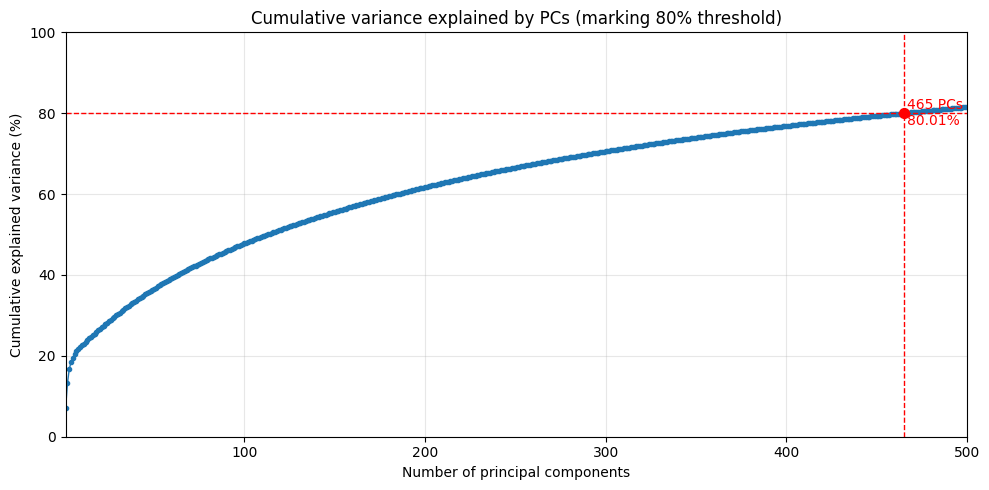

In [62]:
n_pcs_full = min(X.shape[0], X.shape[1])

pca_full = PCA(n_components=n_pcs_full)
pca_full.fit(X)
evr = pca_full.explained_variance_ratio_

cum_var = np.cumsum(evr)  # fraction (0..1)
n_needed = np.searchsorted(cum_var, 0.80) + 1  # PCs required to reach >=80%

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(1, len(evr) + 1)

ax.plot(x, cum_var * 100, marker='o', markersize=3, lw=1)
ax.axhline(80, color='red', linestyle='--', lw=1)
ax.axvline(n_needed, color='red', linestyle='--', lw=1)

ax.scatter([n_needed], [cum_var[n_needed - 1] * 100], color='red', s=50, zorder=5)
ax.text(
        n_needed + 2, 
        cum_var[n_needed - 1] * 100,
        f"{n_needed} PCs\n{cum_var[n_needed - 1]*100:.2f}%", color='red', va='center'
)

ax.set_xlabel("Number of principal components")
ax.set_ylabel("Cumulative explained variance (%)")
ax.set_title("Cumulative variance explained by PCs (marking 80% threshold)")
ax.set_xlim(1, min(len(evr), 500))
ax.set_ylim(0, 100)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---

### Determine Pre-Processing Pipeline with CARVE:

In [82]:
pca_50 = PCA(n_components=50)
X_pca_50 = pca_50.fit_transform(X)
print("X_pca_50 shape:", X_pca_50.shape)

X_pca_50 shape: (14000, 50)


In [83]:
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
idx = next(sss.split(np.arange(len(y)), y))[1]

X_pca_50_sub = X_pca_50[idx]
y_sub = y[idx]

print(f"Subsampled X shape: {X_pca_50_sub.shape}")
print(f"Subsampled y shape: {y_sub.shape}")

Subsampled X shape: (7000, 50)
Subsampled y shape: (7000,)


In [67]:
norm_options = [
    (FunctionTransformer, {}), 
]

dr_options = [
    (PCA, 'pca_11',{
        'n_components': [11]
    }),
    (PCA, 'pca_108',{
        'n_components': [108]
    }),
    (TSNE, 'tsne5',{
        'n_components': [2], 
        'perplexity': [5]
    }),
    (TSNE, 'tsne15',{
        'n_components': [2], 
        'perplexity': [15]
    }),
    (TSNE, 'tsne30',{
        'n_components': [2], 
        'perplexity': [30]
    }),
    (UMAP, 'umap_5',{
        'n_components': [2], 
        'n_neighbors': [5], 
        'min_dist': [0.1]
    }),
    (UMAP, 'umap_10',{
        'n_components': [2], 
        'n_neighbors': [10], 
        'min_dist': [0.1]
    }),
    (UMAP, {
        'n_components': [2], 
        'n_neighbors': [15], 
        'min_dist': [0.1]
    }),
]

cfg = ValidatorConfig(
    X=X_pca_50_sub,
    K=10,
    B=100,
    # norm_options=norm_options,
    # dr_options=dr_options,
    ref_labels=y_sub
)

val = CARVE(cfg)
val.validate(random_preprocess=False, random_state=42)

Grid configs:   0%|          | 0/81 [00:00<?, ?it/s]

In [68]:
# val.plot_preprocessing_results()

In [69]:
val.plot_results()

/Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/_selection.py:62: RuntimeWarning:

No models within quantile thresholds; falling back to max.



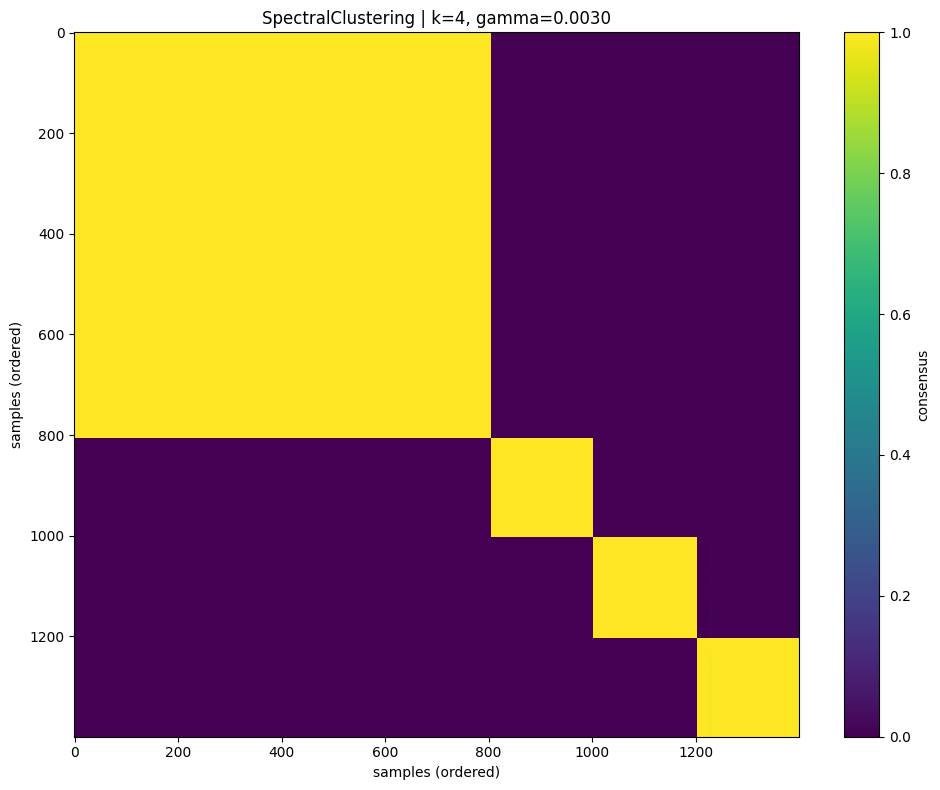

In [80]:
val.plot_consensus_matrix()

In [72]:
val.plot_clustering()

FigureWidget({
    'data': [{'customdata': {'bdata': ('AAAAAAAANUAAAAAAAAAAAAAAAAAAAP' ... 'Nq1FT/7z9/ENQI4f7vPwAAAAAAAPA/'),
                             'dtype': 'f8',
                             'shape': '196, 6'},
              'hovertemplate': ('sample %{customdata[0]}<br>clu' ... 'tomdata[5]:.4f}<extra></extra>'),
              'legendgroup': 'cluster-0',
              'marker': {'color': '#636EFA',
                         'line': {'color': 'black', 'width': 1.0},
                         'opacity': 0.3,
                         'size': {'bdata': ('8WFX9mjJKkBEO+WphsgqQPzuY2kz1S' ... 'NpM9UqQH6XlPjbxypAbyfgaLfGKkA='),
                                  'dtype': 'f8'}},
              'mode': 'markers',
              'name': 'cluster 1',
              'showlegend': True,
              'type': 'scatter',
              'uid': '631334af-13e7-4b03-aab7-016c12fd98b9',
              'x': {'bdata': ('QvakQEO+BUEPVgZBwcThQAkkK0HBD+' ... 'CCJg1BSiE+QY7Z30C7mkBBDueoQA=='),
                 

In [ ]:
spectral = SpectralClustering(n_clusters=4, affinity='rbf', gamma=0.003, random_state=42)
pred_labels = spectral.fit_predict(X_pca_50_sub)
# ari = adjusted_rand_score(y_sub, pred_labels)
# print(f"ARI of SpectralClustering (gamma=0.003) with true labels: {ari:.4f}")

ARI of SpectralClustering (gamma=0.003) with true labels: 0.4029


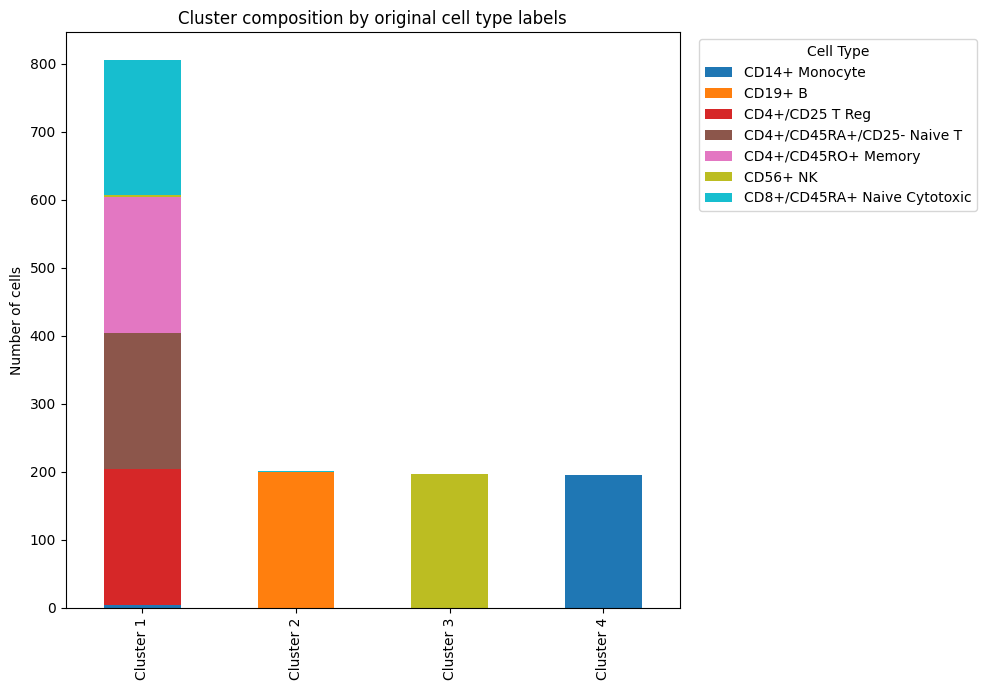

In [79]:
from collections import Counter

n_clusters = 4
spectral = SpectralClustering(n_clusters=n_clusters, affinity='rbf', gamma=0.003, random_state=42)
cluster_labels = spectral.fit_predict(X_pca_50_sub)

# Get cluster composition
cluster_composition = []
categories = y_sub.categories
for i in range(n_clusters):
    idx = np.where(cluster_labels == i)[0]
    labels_in_cluster = y_sub[idx]
    counts = Counter(labels_in_cluster)
    cluster_composition.append([counts.get(cat, 0) for cat in categories])

# Convert to DataFrame for plotting
comp_df = pd.DataFrame(cluster_composition, columns=categories, index=[f'Cluster {i+1}' for i in range(n_clusters)])

# Plot
comp_df.plot(kind='bar', stacked=True, figsize=(10, 7), colormap='tab10')
plt.ylabel('Number of cells')
plt.title('Cluster composition by original cell type labels')
plt.legend(title='Cell Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
### Determine Optimal Clustering with CARVE:

In [25]:
pca = PCA(n_components=11)
X_sub_pca = pca.fit_transform(X_sub)
print("X_sub_pca shape:", X_sub_pca.shape)

X_sub_pca shape: (1400, 11)


In [26]:
cfg = ValidatorConfig(
    X=X_sub_pca,
    K=10,
    B=100,
    ref_labels=y_sub
)

val = CARVE(cfg)
val.validate(random_preprocess=False, random_state=42)

Grid configs:   0%|          | 0/81 [00:00<?, ?it/s]

In [27]:
val.plot_results(measure='s', rule='1se')

/Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/_selection.py:62: RuntimeWarning:

No models within quantile thresholds; falling back to max.



In [28]:
val.plot_results(measure='g', rule='1se')

/Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/_selection.py:62: RuntimeWarning:

No models within quantile thresholds; falling back to max.



/Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/_plotting.py:474: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



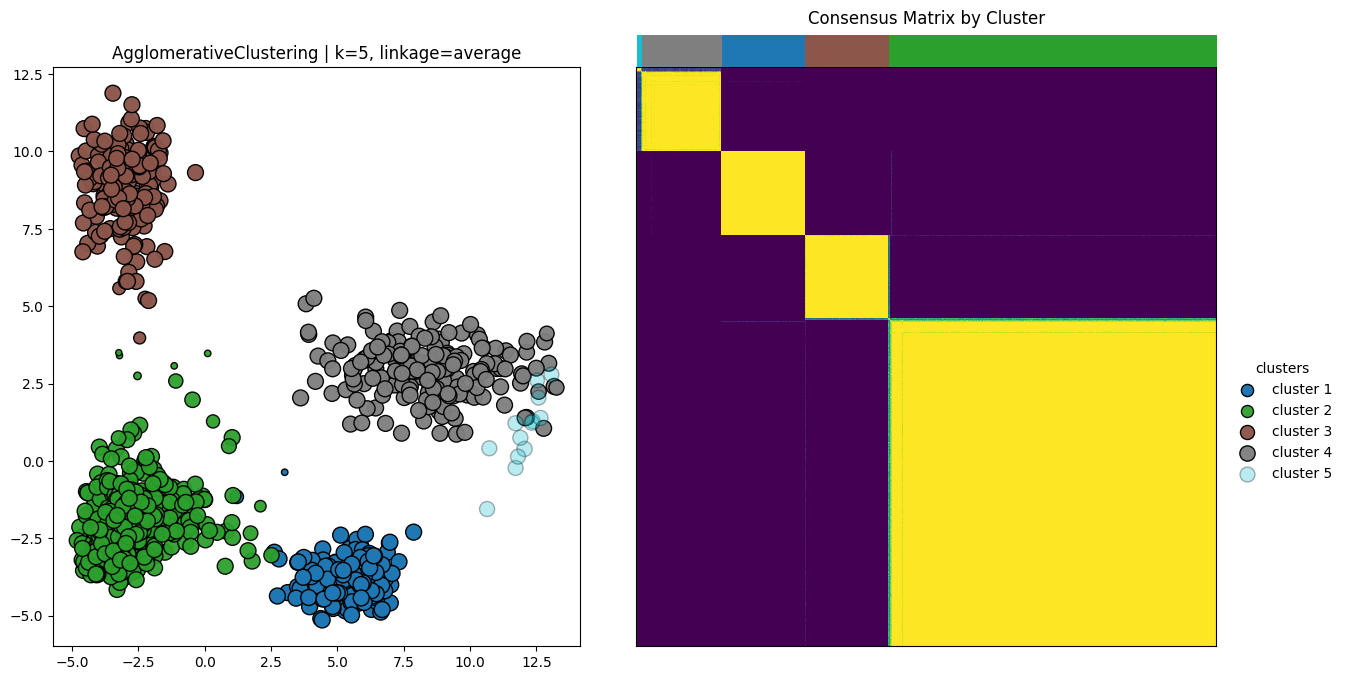

In [37]:
val.plot_consensus_clustering(k=5, figsize=(15, 8))

In [38]:
val.plot_clustering(k=5, measure='s', rule='1se')

FigureWidget({
    'data': [{'customdata': {'bdata': ('AAAAAAAA8D8AAAAAAAAAAAAAAAAAAP' ... '7jS/rG7z+tY1xTC8DvPwAAAAAAAPA/'),
                             'dtype': 'f8',
                             'shape': '790, 6'},
              'hovertemplate': ('sample %{customdata[0]}<br>clu' ... 'tomdata[5]:.4f}<extra></extra>'),
              'legendgroup': 'cluster-0',
              'marker': {'color': '#636EFA',
                         'line': {'color': 'black', 'width': 1.0},
                         'opacity': 0.9425330179395288,
                         'size': {'bdata': ('hrIHJ5y5KkDyHzbLxLoqQFWvE6N5uS' ... 'COlroqQCFbdGnCvSpApd6FD7W5KkA='),
                                  'dtype': 'f8'}},
              'mode': 'markers',
              'name': 'cluster 1',
              'showlegend': True,
              'type': 'scatter',
              'uid': '17608ea7-702c-444f-a461-9162c8305fe3',
              'x': {'bdata': ('DhpnwMQmMMC2cuK/osuBwCWPYsD8IS' ... 'CB3T3AKNhSwOL/M8AToYnATMEnwA=='),
  

In [39]:
agg = AgglomerativeClustering(n_clusters=5, linkage='average')
pred_labels = agg.fit_predict(X_sub_pca)
ari = adjusted_rand_score(y_sub, pred_labels)
print(f"ARI of AgglomerativeClustering (ward linkage) with true labels: {ari:.4f}")

ARI of AgglomerativeClustering (ward linkage) with true labels: 0.0000
